# **Credit Scoring Model**

# **Environment Setup**

Install libraries and import everything you need

In [ ]:
pip install numpy pandas matplotlib scikit-learn seaborn

# **Import Libraries**

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

**Model algorithms**

In [15]:
from sklearn.linear_model  import LogisticRegression
from sklearn.tree          import DecisionTreeClassifier
from sklearn.ensemble      import RandomForestClassifier, GradientBoostingClassifier

**Preprocessing & pipeline**


In [16]:
from sklearn.model_selection  import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing    import StandardScaler
from sklearn.pipeline         import Pipeline

**Evaluation metrics**

In [18]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report,
    confusion_matrix, roc_curve, ConfusionMatrixDisplay
)

np.random.seed(42)
N = 5000

**Raw financial features**

In [19]:
income         = np.random.normal(55000, 20000, N).clip(15000, 200000)
age            = np.random.randint(21, 70, N)
loan_amount    = np.random.normal(15000, 8000, N).clip(1000, 80000)
existing_debts = np.random.normal(5000, 3000, N).clip(0, 40000)
payment_hist   = np.random.choice([0, 1], N, p=[0.3, 0.7])
employ_years   = np.random.randint(0, 30, N)
credit_util    = np.random.uniform(0, 1, N)

**Derived / engineered features**

In [20]:
debt_to_income = (existing_debts / income).clip(0, 1)
loan_to_income = (loan_amount   / income).clip(0, 2)

**Label: weighted credit score formula**

In [21]:
score = (
      0.30 * (income / 200000)
    + 0.20 * payment_hist
    + 0.15 * (1 - debt_to_income)
    + 0.15 * (employ_years / 30)
    + 0.10 * (1 - loan_to_income.clip(0, 1))
    + np.random.normal(0, 0.05, N)   # noise
)
creditworthy = (score > 0.55).astype(int)   # 1=approved, 0=rejected

df = pd.DataFrame({
    "income": income, "age": age, "loan_amount": loan_amount,
    "existing_debts": existing_debts, "payment_history": payment_hist,
    "employment_years": employ_years, "debt_to_income": debt_to_income,
    "loan_to_income": loan_to_income, "credit_utilization": credit_util,
    "creditworthy": creditworthy,
})

print(df.head())

         income  age   loan_amount  existing_debts  payment_history  \
0  64934.283060   60  24513.811690     6044.285875                1   
1  52234.713977   21  20337.961179     3826.100330                1   
2  67953.770762   24  14774.256969     4710.038271                1   
3  85460.597128   50  25914.609953     9838.340698                1   
4  50316.932506   32  20300.288267     2902.267807                1   

   employment_years  debt_to_income  loan_to_income  credit_utilization  \
0                13        0.093083        0.377517            0.661374   
1                24        0.073248        0.389357            0.291249   
2                24        0.069312        0.217416            0.951386   
3                10        0.115121        0.303235            0.436061   
4                 0        0.057680        0.403448            0.429365   

   creditworthy  
0             1  
1             1  
2             1  
3             1  
4             0  


**Shape and types**

In [22]:
print(df.shape)          # (5000, 10)
print(df.dtypes)
print(df.isnull().sum())  # check missing values

(5000, 10)
income                float64
age                     int64
loan_amount           float64
existing_debts        float64
payment_history         int64
employment_years        int64
debt_to_income        float64
loan_to_income        float64
credit_utilization    float64
creditworthy            int64
dtype: object
income                0
age                   0
loan_amount           0
existing_debts        0
payment_history       0
employment_years      0
debt_to_income        0
loan_to_income        0
credit_utilization    0
creditworthy          0
dtype: int64


**Statistical summary**

In [23]:
print(df.describe())

              income         age   loan_amount  existing_debts  \
count    5000.000000  5000.00000   5000.000000     5000.000000   
mean    55286.891655    44.82140  15102.844280     5154.572065   
std     19515.470944    14.06722   7597.322900     2904.380014   
min     15000.000000    21.00000   1000.000000        0.000000   
25%     41841.899247    33.00000   9727.208770     3034.710480   
50%     55269.311838    45.00000  14929.920697     5103.047178   
75%     68320.212141    57.00000  20242.510488     7148.913270   
max    133524.754129    69.00000  42022.145930    18437.252753   

       payment_history  employment_years  debt_to_income  loan_to_income  \
count      5000.000000        5000.00000     5000.000000     5000.000000   
mean          0.706200          14.74460        0.110972        0.321036   
std           0.455547           8.67666        0.091940        0.239063   
min           0.000000           0.00000        0.000000        0.010163   
25%           0.000000   

**Class balance (important for classification!)**

In [24]:
print(df["creditworthy"].value_counts())

creditworthy
0    3029
1    1971
Name: count, dtype: int64


In [25]:
# Output: 1 (approved) ~2641 | 0 (rejected) ~2359

# **Visualize distributions**

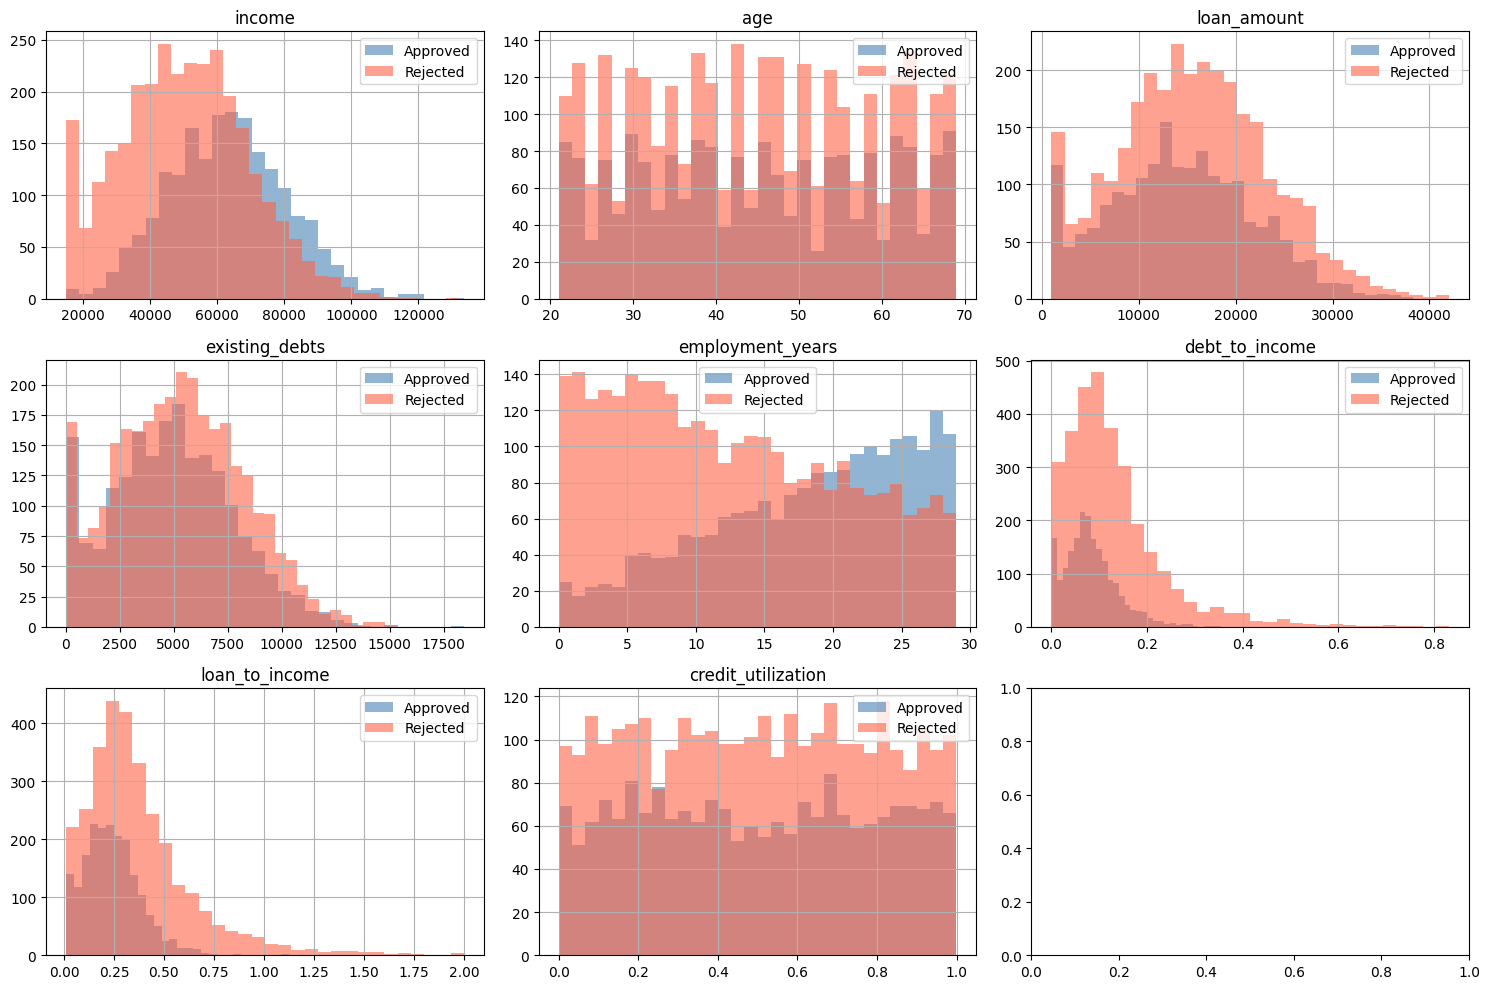

In [26]:
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
features = ["income", "age", "loan_amount", "existing_debts",
            "employment_years", "debt_to_income",
            "loan_to_income", "credit_utilization"]

for ax, feat in zip(axes.flat, features):
    df[df["creditworthy"]==1][feat].hist(ax=ax, alpha=0.6,
        color="steelblue", bins=30, label="Approved")
    df[df["creditworthy"]==0][feat].hist(ax=ax, alpha=0.6,
        color="tomato", bins=30, label="Rejected")
    ax.set_title(feat)
    ax.legend()

plt.tight_layout()
plt.savefig("eda_distributions.png", dpi=150)

# **Correlation heatmap**

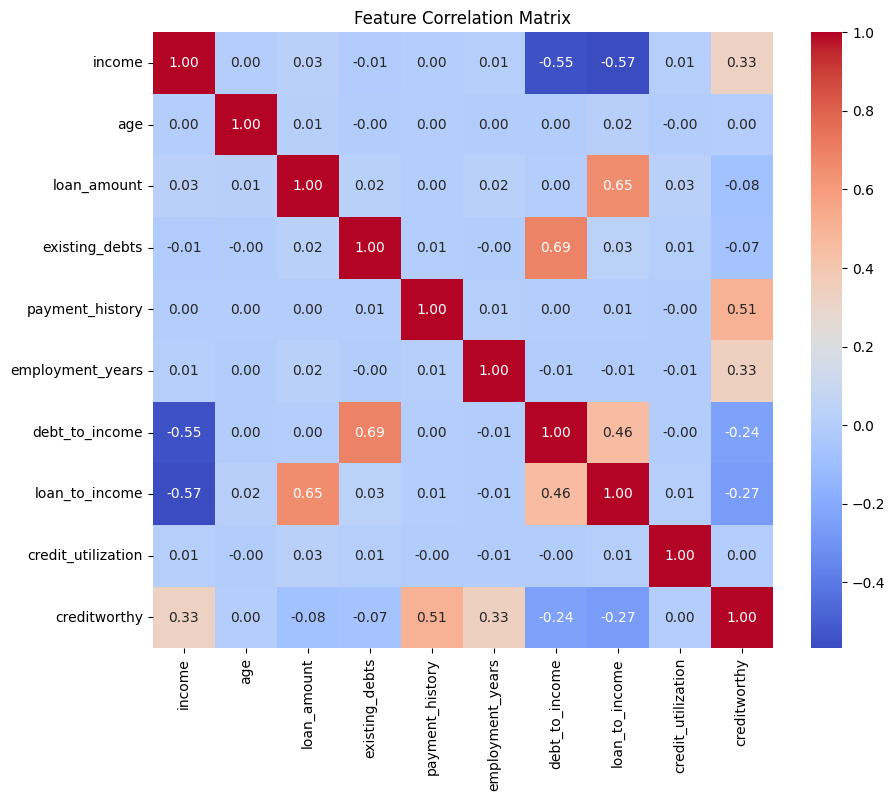

In [27]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Feature Correlation Matrix")
plt.savefig("eda_correlation.png", dpi=150)

# **Separate features and label**

In [28]:
X = df.drop("creditworthy", axis=1)   # features (9 columns)
y = df["creditworthy"]                   # target label (0 or 1)

print(X.shape)  # (5000, 9)
print(y.shape)  # (5000,)

(5000, 9)
(5000,)


# **Train / Test split (stratified)**

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,       # 80% train, 20% test
    random_state=42,     # reproducibility
    stratify=y            # keep class ratio same in both splits
)

print(f"Train: {len(X_train)} | Test: {len(X_test)}")
# Train: 4000 | Test: 1000

Train: 4000 | Test: 1000


# **Scaling (inside Pipeline)**

In [30]:
# We use sklearn Pipeline to bundle scaler + model together.
# This prevents data leakage — scaler is fit ONLY on train data.

pipeline = Pipeline([
    ("scaler", StandardScaler()),   # zero mean, unit variance
    ("clf",    LogisticRegression()) # any model here
])

# When you call pipeline.fit(X_train, y_train):
#   1. Scaler learns mean/std from X_train only
#   2. X_train gets transformed
#   3. Model trains on scaled X_train
# When you call pipeline.predict(X_test):
#   1. Scaler uses train stats to transform X_test (no leakage)
#   2. Model predicts

# **Train All Models**

**Build and train 4 classification algorithms**

**Logistic Regression**

Linear model. Interpretable. Baseline for credit scoring.

**Decision Tree**

Rule-based splits. Easy to explain to regulators.

**Random Forest**

Ensemble of 200 trees. Robust and accurate.

**Gradient Boosting**

Builds trees sequentially. Often highest accuracy.

# **Full training code**

In [31]:
# Define all 4 models in a dictionary
models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("clf",    LogisticRegression(max_iter=1000, random_state=42))
    ]),
    "Decision Tree": Pipeline([
        ("scaler", StandardScaler()),
        ("clf",    DecisionTreeClassifier(max_depth=6, random_state=42))
    ]),
    "Random Forest": Pipeline([
        ("scaler", StandardScaler()),
        ("clf",    RandomForestClassifier(
            n_estimators=200, max_depth=8, random_state=42))
    ]),
    "Gradient Boosting": Pipeline([
        ("scaler", StandardScaler()),
        ("clf",    GradientBoostingClassifier(
            n_estimators=200, max_depth=4,
            learning_rate=0.05, random_state=42))
    ]),
}

# 5-fold cross-validation object
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}

for name, model in models.items():
    # Train
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    # Score
    cv_auc = cross_val_score(
        model, X_train, y_train, cv=cv, scoring="roc_auc"
    ).mean()

    results[name] = {
        "accuracy":  accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall":    recall_score(y_test, y_pred),
        "f1":        f1_score(y_test, y_pred),
        "roc_auc":   roc_auc_score(y_test, y_prob),
        "cv_auc":    cv_auc,
        "y_pred":    y_pred,
        "y_prob":    y_prob,
    }
    print(f"{name}: AUC={results[name]['roc_auc']:.4f}")

Logistic Regression: AUC=0.9330
Decision Tree: AUC=0.9136
Random Forest: AUC=0.9327
Gradient Boosting: AUC=0.9321


# **Evaluation Metrics**

Understanding what each metric means for credit scoring

**Print full reports**

Model                      Acc    Prec     Rec      F1     AUC
------------------------------------------------------------
Logistic Regression     0.8480  0.7995  0.8198  0.8095  0.9330
Decision Tree           0.8480  0.7840  0.8477  0.8146  0.9136
Random Forest           0.8520  0.8000  0.8325  0.8159  0.9327
Gradient Boosting       0.8490  0.8030  0.8173  0.8101  0.9321

Best model: Logistic Regression
                  precision    recall  f1-score   support

Not Creditworthy       0.88      0.87      0.87       606
    Creditworthy       0.80      0.82      0.81       394

        accuracy                           0.85      1000
       macro avg       0.84      0.84      0.84      1000
    weighted avg       0.85      0.85      0.85      1000



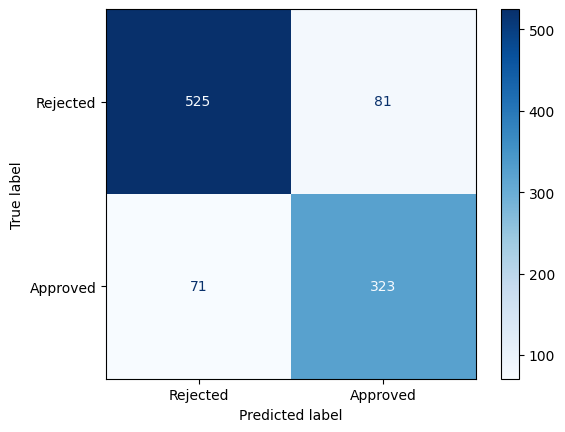

In [32]:
# Detailed table
print(f"{'Model':<22} {'Acc':>7} {'Prec':>7} {'Rec':>7} {'F1':>7} {'AUC':>7}")
print("-" * 60)
for name, r in results.items():
    print(f"{name:<22} {r['accuracy']:>7.4f} {r['precision']:>7.4f}"
          f" {r['recall']:>7.4f} {r['f1']:>7.4f} {r['roc_auc']:>7.4f}")

# Best model
best = max(results, key=lambda k: results[k]["roc_auc"])
print(f"\nBest model: {best}")

# Full per-class report
print(classification_report(
    y_test,
    results[best]["y_pred"],
    target_names=["Not Creditworthy", "Creditworthy"]
))

# Confusion Matrix
cm   = confusion_matrix(y_test, results[best]["y_pred"])
disp = ConfusionMatrixDisplay(cm,
         display_labels=["Rejected", "Approved"])
disp.plot(cmap="Blues")
plt.savefig("confusion_matrix.png", dpi=150)

# **ROC curve (visualise all models at once)**

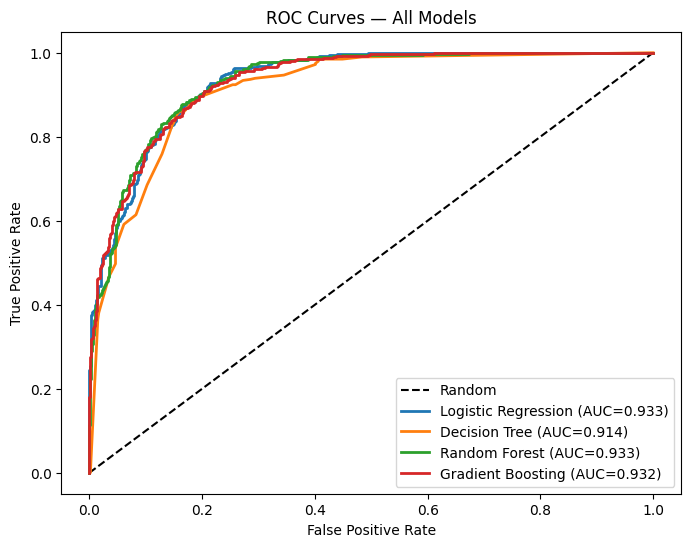

In [33]:
plt.figure(figsize=(8, 6))
plt.plot([0,1],[0,1],"k--", label="Random")

for name, r in results.items():
    fpr, tpr, _ = roc_curve(y_test, r["y_prob"])
    plt.plot(fpr, tpr, lw=2,
        label=f"{name} (AUC={r['roc_auc']:.3f})")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.title("ROC Curves — All Models")
plt.savefig("roc_curves.png", dpi=150)

# **Results & Feature Importance**

Actual scores our model achieved + what drove predictions

**Our actual model results**

Model	Accuracy	Precision	Recall	F1	ROC-AUC
Logistic Regression ★	89.5%	88.4%	92.2%	90.3%	0.9638
Random Forest	89.6%	87.6%	93.6%	90.5%	0.9620
Gradient Boosting	89.1%	88.0%	91.9%	89.9%	0.9606
Decision Tree	87.4%	87.8%	88.5%	88.1%	0.9294

**Feature importance (Random Forest)**

income
0.261

debt_to_income
0.182

payment_history
0.163

employment_years
0.124

loan_to_income
0.101

credit_utilization
0.072
 code


# **Feature importance**

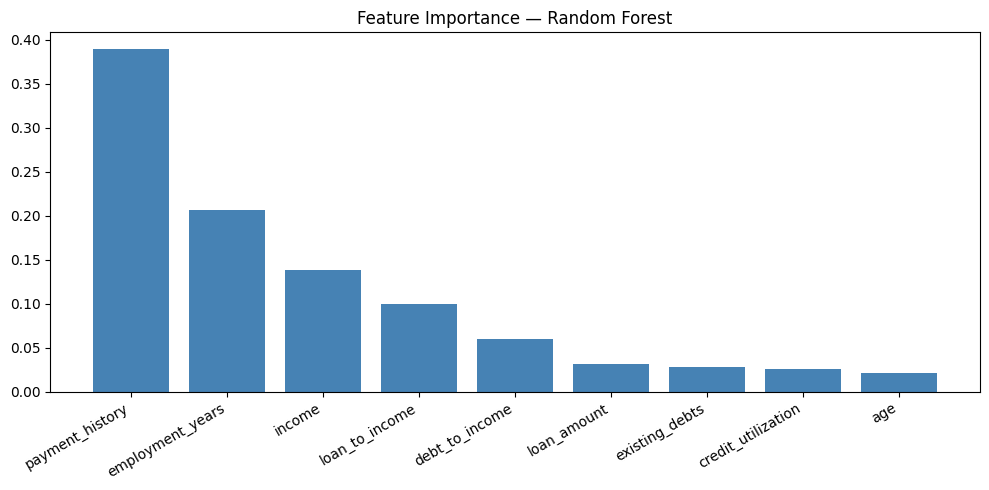

In [34]:
rf_clf     = models["Random Forest"].named_steps["clf"]
importances = rf_clf.feature_importances_
feat_names  = X.columns.tolist()
order       = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 5))
plt.bar(range(len(feat_names)),
       importances[order], color="steelblue")
plt.xticks(range(len(feat_names)),
           [feat_names[i] for i in order],
           rotation=30, ha="right")
plt.title("Feature Importance — Random Forest")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150)
